In [45]:
!git clone https://github.com/karolpiczak/ESC-50.git

fatal: destination path 'ESC-50' already exists and is not an empty directory.


In [46]:
import librosa
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
from tqdm import tqdm # Biblioteca para mostrar uma barra de progresso
warnings.filterwarnings('ignore')

### 1. Upload do Dataset e Extração de Features Probabilísticas

Aqui definimos parâmetros como a taxa de amostragem sendo 16kHz e a extração de 40 características acústicas (MFCCs).

Definimos que as categorias 0 a 24 seriam o som padrão do ambiente, enquanto as categorias 40 a 49 seriam as anomalias.

Dividimos os sons normais em 80% para treino e 20% para teste, enquanto 100% dos sons anômalos são reservados para teste, isso porque o sistema aprende apenas o que é "normal".

In [47]:
caminho_csv = 'ESC-50/meta/esc50.csv'
pasta_audio = 'ESC-50/audio/'

In [48]:
#TAXA_AMOSTRAGEM = 16000
#N_MFCC = 40

In [49]:
df = pd.read_csv(caminho_csv)

In [50]:
df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [51]:
def extrair_caracteristicas_probabilisticas_seguro(caminho_audio):
    """
    Mesma extração do notebook original, mas com o skew protegido
    contra NaN/Inf (que ocorrem quando um trecho do áudio tem
    variância ~0, comum em silêncios no início/fim dos clipes do
    ESC-50).
    """
    import librosa
    import scipy.stats as stats

    y, sr = librosa.load(caminho_audio, sr=44100)

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, fmax=22000)
    delta_mfccs = librosa.feature.delta(mfccs)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)

    features_globais = []
    for feat in [mfccs, delta_mfccs, centroid, rolloff, zcr]:
        features_globais.append(np.mean(feat, axis=1))
        features_globais.append(np.std(feat, axis=1))
        with np.errstate(invalid="ignore", divide="ignore"):
            sk = stats.skew(feat, axis=1)
        sk = np.nan_to_num(sk, nan=0.0, posinf=0.0, neginf=0.0)
        features_globais.append(sk)

    return np.concatenate(features_globais)

In [52]:
import pandas as pd
import os

todas_features = []

# 2. Itere sobre a coluna de nomes
for nome_arquivo in df['filename']:
    caminho_completo = os.path.join(pasta_audio, nome_arquivo)

    # Passa a rota de texto limpa para a função original que você criou
    features = extrair_caracteristicas_probabilisticas(caminho_completo)
    todas_features.append(features)

# 3. Consolida as características extraídas em um novo DataFrame
df_features = pd.DataFrame(todas_features)

In [53]:
df_features.head()

,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,-581.796753,8.196110,-6.660087,-4.292468,-3.028214,0.257634,-1.970501,-0.260889,0.514987,0.347961,...,1.827954,273.927703,1168.622069,6.381527,436.259698,2074.699983,7.197874,0.007329,0.027503,4.345379
1,-254.526138,85.296440,-106.619789,30.762413,-39.781559,-17.458523,-37.051598,-18.173023,-11.608204,-17.716209,...,-0.143671,4042.281204,536.421310,0.595749,6623.483383,630.853580,1.150016,0.157994,0.022784,0.254124
2,-30.199627,102.162514,-40.145908,38.829121,-22.300877,12.617256,-8.276701,20.543255,-11.472058,18.834251,...,-0.605137,4410.555928,391.361066,-2.489852,8364.425369,570.864187,-4.112720,0.199469,0.029614,-4.015615
3,-30.824329,103.949860,-42.788315,42.154835,-26.107906,18.162012,-10.358107,22.169420,-12.143396,16.495958,...,-0.357046,4370.451735,223.974376,-0.179527,8421.281019,313.179684,0.441502,0.202079,0.021309,-1.740700
4,-466.469269,144.097900,23.124413,52.125362,3.010296,11.253691,-2.873207,0.003247,-8.876951,10.021020,...,-0.085983,2075.738865,585.039587,-0.104186,4559.843116,1906.502683,-0.644913,0.027574,0.010662,0.818237


In [54]:
# 1. Gerar a lista de 87 nomes na ordem correta
colunas_audio = []
estatisticas = ['mean', 'std', 'skew']

for stat in estatisticas:
    for i in range(1, 14): colunas_audio.append(f'mfcc_{i}_{stat}')
for stat in estatisticas:
    for i in range(1, 14): colunas_audio.append(f'delta_mfcc_{i}_{stat}')
for feat in ['centroid', 'rolloff', 'zcr']:
    for stat in estatisticas: colunas_audio.append(f'{feat}_{stat}')

# 2. Substituir os nomes do seu DataFrame EXISTENTE
# Troque "df_audio" pelo nome da variável onde estão suas 87 colunas hoje
df_features.columns = colunas_audio

In [55]:
df_features.head()

,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,...,delta_mfcc_13_skew,centroid_mean,centroid_std,centroid_skew,rolloff_mean,rolloff_std,rolloff_skew,zcr_mean,zcr_std,zcr_skew
0,-581.796753,8.196110,-6.660087,-4.292468,-3.028214,0.257634,-1.970501,-0.260889,0.514987,0.347961,...,1.827954,273.927703,1168.622069,6.381527,436.259698,2074.699983,7.197874,0.007329,0.027503,4.345379
1,-254.526138,85.296440,-106.619789,30.762413,-39.781559,-17.458523,-37.051598,-18.173023,-11.608204,-17.716209,...,-0.143671,4042.281204,536.421310,0.595749,6623.483383,630.853580,1.150016,0.157994,0.022784,0.254124
2,-30.199627,102.162514,-40.145908,38.829121,-22.300877,12.617256,-8.276701,20.543255,-11.472058,18.834251,...,-0.605137,4410.555928,391.361066,-2.489852,8364.425369,570.864187,-4.112720,0.199469,0.029614,-4.015615
3,-30.824329,103.949860,-42.788315,42.154835,-26.107906,18.162012,-10.358107,22.169420,-12.143396,16.495958,...,-0.357046,4370.451735,223.974376,-0.179527,8421.281019,313.179684,0.441502,0.202079,0.021309,-1.740700
4,-466.469269,144.097900,23.124413,52.125362,3.010296,11.253691,-2.873207,0.003247,-8.876951,10.021020,...,-0.085983,2075.738865,585.039587,-0.104186,4559.843116,1906.502683,-0.644913,0.027574,0.010662,0.818237


In [56]:
# 3. Juntar com o seu outro dataset
# Troque "df_outro" pelo nome do seu segundo dataset
df_processado = pd.concat([df, df_features], axis=1)

In [57]:
print(df.shape)
print(df_features.shape)
print(df_processado.shape)

(2000, 7)
(2000, 87)
(2000, 94)


In [58]:
df_processado.head()

,filename,fold,target,category,esc10,src_file,take,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,...,delta_mfcc_13_skew,centroid_mean,centroid_std,centroid_skew,rolloff_mean,rolloff_std,rolloff_skew,zcr_mean,zcr_std,zcr_skew
0,1-100032-A-0.wav,1,0,dog,True,100032,A,-581.796753,8.196110,-6.660087,...,1.827954,273.927703,1168.622069,6.381527,436.259698,2074.699983,7.197874,0.007329,0.027503,4.345379
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,-254.526138,85.296440,-106.619789,...,-0.143671,4042.281204,536.421310,0.595749,6623.483383,630.853580,1.150016,0.157994,0.022784,0.254124
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A,-30.199627,102.162514,-40.145908,...,-0.605137,4410.555928,391.361066,-2.489852,8364.425369,570.864187,-4.112720,0.199469,0.029614,-4.015615
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B,-30.824329,103.949860,-42.788315,...,-0.357046,4370.451735,223.974376,-0.179527,8421.281019,313.179684,0.441502,0.202079,0.021309,-1.740700
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A,-466.469269,144.097900,23.124413,...,-0.085983,2075.738865,585.039587,-0.104186,4559.843116,1906.502683,-0.644913,0.027574,0.010662,0.818237


### 1.1 Separando anomalia e normal / Divisão Treino Teste

In [59]:
df_normal = df_processado[df_processado['target'] <= 24].copy()
df_anomalia = df_processado[df_processado['target'] >= 40].copy()

In [61]:
df_normal_treino , df_normal_teste = train_test_split(
    df_normal,
    test_size=0.20,
    stratify=df_normal["category"],
    random_state=42
)

In [62]:
print(f"Áudios normais para treino: {len(df_normal_treino)}")
print(f"Áudios normais para teste: {len(df_normal_teste)}")
print(f"Áudios anômalos para teste: {len(df_anomalia)}")

Áudios normais para treino: 800
Áudios normais para teste: 200
Áudios anômalos para teste: 400


### 1.2 Padronizando os dados para os modelos KDE e GMM

In [63]:
df_normal_treino.values

array([['3-178096-A-6.wav', 3, 6, ..., 0.04627002972737819,
        0.009568850745380763, 0.49491527229760934],
       ['4-188703-A-8.wav', 4, 8, ..., 0.02318259679524362,
        0.009559745830418532, -0.4416797759811942],
       ['2-98676-A-24.wav', 2, 24, ..., 0.010737655887470998,
        0.023262948945602664, 2.47453119898401],
       ...,
       ['4-164064-B-1.wav', 4, 1, ..., 0.02892528277262181,
        0.03796851834530353, 0.6960366241751889],
       ['4-144085-A-16.wav', 4, 16, ..., 0.02080010150812065,
        0.0028816704544842764, 0.09553152535592993],
       ['4-144083-C-16.wav', 4, 16, ..., 0.02402547672563805,
        0.0037726939868197766, 0.014255052968267262]], dtype=object)

In [64]:
from sklearn.preprocessing import StandardScaler

#Guardando a variavel alvo
Y_train_normal = df_normal_treino['target'].values
Y_test_normal = df_normal_teste['target'].values
Y_anomalia = df_anomalia['target'].values

# 1. Isolar apenas as colunas de características (as 87 colunas)
# Se os seus dataframes tiverem colunas de ID ou rótulo (ex: 'classe'), remova-as antes:
df_normal_treino = df_normal_treino.drop(columns=['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take'])
df_normal_teste = df_normal_teste.drop(columns=['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take'])
#df_anomalia = df_anomalia.drop(columns=['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take'])

In [65]:
df_anomalia = df_anomalia.drop(columns=['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take'])

In [66]:
X_train_normal = df_normal_treino.values
X_test_normal = df_normal_teste.values
X_anomalia = df_anomalia.values

In [67]:
df_normal_treino.head()

,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,...,delta_mfcc_13_skew,centroid_mean,centroid_std,centroid_skew,rolloff_mean,rolloff_std,rolloff_skew,zcr_mean,zcr_std,zcr_skew
1114,-232.408310,192.387070,-43.519966,-43.033569,-16.413885,-35.356518,-8.376814,16.520983,9.633388,2.872116,...,0.243491,1353.317965,266.251812,0.864923,2118.297632,726.342046,0.619542,0.046270,0.009569,0.494915
1464,-300.719574,182.233505,14.744732,-2.345640,18.132660,-1.925110,-4.110326,7.890266,4.561177,2.314539,...,0.186303,916.075523,279.443332,-0.213438,1713.163655,631.922177,0.060481,0.023183,0.009560,-0.441680
793,-710.607117,33.585899,4.008609,4.722785,-4.863234,6.611898,4.230757,3.012797,-1.478517,0.182256,...,-1.581472,836.724528,1534.305053,2.370394,1973.460611,3579.398899,1.758617,0.010738,0.023263,2.474531
1938,-391.491394,136.993759,-0.497630,-22.742002,-20.251844,-5.190505,0.869237,13.480953,5.649131,-3.993154,...,0.125088,2346.372201,1532.307434,1.210843,4432.942104,4400.050967,1.063536,0.051123,0.022932,1.768707
1846,-193.596603,153.988800,-87.072792,19.051748,-35.807392,4.309021,-21.024630,-0.127217,-19.035341,-0.661449,...,-0.110126,2811.741757,356.895453,0.316176,5166.569841,850.094943,0.412106,0.088406,0.014357,0.126208


In [68]:
def sanitizar_features(X, nome=""):
    """
    Rede de segurança adicional: aplique isso logo após montar a
    matriz de features (antes do StandardScaler/PCA), mesmo já usando
    a extração segura acima — protege contra qualquer NaN/Inf residual.
    """
    X = np.asarray(X, dtype=float)
    n_nan = np.isnan(X).sum()
    n_inf = np.isinf(X).sum()
    if n_nan or n_inf:
        print(f"[{nome}] {n_nan} NaN e {n_inf} Inf encontrados -> substituindo")
    return np.nan_to_num(X, nan=0.0, posinf=np.finfo(np.float64).max,
                          neginf=np.finfo(np.float64).min)

In [69]:
X_train_normal = sanitizar_features(X_train_normal, nome="Treino normal")
X_test_normal = sanitizar_features(X_test_normal, nome="Teste normal")
X_anomalia = sanitizar_features(X_anomalia, nome="Teste anomalia")

In [70]:
#Inicializar o Scaler
scaler = StandardScaler()

# 3. Ajustar o scaler APENAS nos dados normais de treino e transformar
X_train_normal_scaled = scaler.fit_transform(X_train_normal)

# 4. Transformar os dados de teste usando a MESMA escala aprendida no treino
X_test_normal_scaled = scaler.transform(X_test_normal)
X_anomalia_scaled = scaler.transform(X_anomalia)


In [71]:
pca = PCA(n_components=15, svd_solver="full", random_state=42)
pca.fit(X_train_normal_scaled)

X_train_normal_pca = pca.transform(X_train_normal_scaled)
X_anomalia_pca = pca.transform(X_anomalia_scaled)
X_test_normal_pca = pca.transform(X_test_normal_scaled)

### 2. Implementação básica de GMM e KDE

In [72]:
df_gmm1 = df_processado[df_processado['target'] <= 24].copy()
df_gmm2 = df_processado[df_processado['target'] >= 40].copy()

In [73]:
df_gmm = pd.concat([df_gmm1, df_gmm2], ignore_index=True)

In [74]:
df_gmm.head()

,filename,fold,target,category,esc10,src_file,take,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,...,delta_mfcc_13_skew,centroid_mean,centroid_std,centroid_skew,rolloff_mean,rolloff_std,rolloff_skew,zcr_mean,zcr_std,zcr_skew
0,1-100032-A-0.wav,1,0,dog,True,100032,A,-581.796753,8.196110,-6.660087,...,1.827954,273.927703,1168.622069,6.381527,436.259698,2074.699983,7.197874,0.007329,0.027503,4.345379
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,-254.526138,85.296440,-106.619789,...,-0.143671,4042.281204,536.421310,0.595749,6623.483383,630.853580,1.150016,0.157994,0.022784,0.254124
2,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A,-466.469269,144.097900,23.124413,...,-0.085983,2075.738865,585.039587,-0.104186,4559.843116,1906.502683,-0.644913,0.027574,0.010662,0.818237
3,1-101296-B-19.wav,1,19,thunderstorm,False,101296,B,-441.661469,153.296112,32.625763,...,0.034103,1850.646524,861.408073,1.042513,3547.033153,2453.819084,0.626852,0.028877,0.018303,1.640057
4,1-103298-A-9.wav,1,9,crow,False,103298,A,-173.015366,131.473816,-23.219978,...,0.132244,2675.116865,522.570959,0.236041,6261.615656,962.173653,-0.804217,0.041329,0.022675,0.808324


In [76]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Manter apenas as colunas numéricas no dataframe (df_gmm)
df_numerico = df_gmm.select_dtypes(include=[np.number])
categorias = df_gmm['target']

# Opcional: Remover a coluna 'fold' se não quiser que o modelo aprenda com ela
if 'fold' in df_numerico.columns:
    df_numerico = df_numerico.drop(columns=['fold'])

# 2. Separar as variáveis preditoras (X) da variável alvo (y)
X = df_numerico.drop(columns=['target'])
y = df_numerico['target']

# 3. Fazer a divisão de treino e teste (ex: 80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # Garante o equilíbrio das classes na divisão
)

print(f"Tamanho do treino: {X_train.shape}")
print(f"Tamanho do teste: {X_test.shape}")

Tamanho do treino: (1120, 88)
Tamanho do teste: (280, 88)


In [83]:
categorias = df_gmm['target']

In [84]:
categorias

,target
0,0
1,14
2,19
3,19
4,9
...,...
1395,49
1396,49
1397,49
1398,49


In [78]:
# ============================================================
# 1. MISTURA DE ESPECIALISTAS SUPERVISIONADA (por categoria real)
# ============================================================
def treinar_mistura_especialistas(X_train_pca, categorias_treino,
                                   n_components=2, covariance_type="diag",
                                   reg_covar=1e-3, min_amostras_por_grupo=15):
    """
    Treina um GaussianMixture por categoria REAL de som normal
    (ex.: 'dog', 'rain', 'crying_baby'...), em vez de usar clusters
    do K-Means. Categorias com poucas amostras são fundidas em um
    grupo residual para não faltar dado para ajustar a covariância.

    X_train_pca         : matriz (n_amostras, n_componentes_pca)
    categorias_treino    : array com a categoria de cada linha de
                           X_train_pca, NA MESMA ORDEM (capture a
                           coluna 'category' ANTES de descartá-la do
                           dataframe de treino)
    """
    especialistas = {}
    categorias_unicas, contagens = np.unique(categorias_treino, return_counts=True)
    grupo_residual = [c for c, n in zip(categorias_unicas, contagens)
                       if n < min_amostras_por_grupo]

    for cat in categorias_unicas:
        if cat in grupo_residual:
            continue
        X_grupo = X_train_pca[categorias_treino == cat]
        k = min(n_components, max(1, len(X_grupo) // 10))
        gmm = GaussianMixture(n_components=k, covariance_type=covariance_type,
                               reg_covar=reg_covar, random_state=42, n_init=5)
        gmm.fit(X_grupo)
        especialistas[cat] = gmm

    if grupo_residual:
        mascara = np.isin(categorias_treino, grupo_residual)
        X_residual = X_train_pca[mascara]
        if len(X_residual) >= min_amostras_por_grupo:
            gmm = GaussianMixture(n_components=1, covariance_type=covariance_type,
                                   reg_covar=reg_covar, random_state=42, n_init=5)
            gmm.fit(X_residual)
            especialistas["__residual__"] = gmm
        else:
            print(f"Aviso: grupo residual com apenas {len(X_residual)} amostras "
                  f"({grupo_residual}) — descartado por falta de dados.")

    print(f"Especialistas treinados: {list(especialistas.keys())}")
    return especialistas


def score_mistura_especialistas(especialistas, X):
    """Para cada amostra, usa o especialista que melhor a explica (log-likelihood máximo)."""
    scores = np.array([gmm.score_samples(X) for gmm in especialistas.values()])
    return np.max(scores, axis=0)

In [85]:
especialista = treinar_mistura_especialistas(X_train, categorias)

Especialistas treinados: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49)]


In [86]:
scores_test = score_mistura_especialistas(
    especialista,
    X_test
)

In [24]:
import numpy as np
from sklearn.metrics import classification_report

# Criando os rótulos de teste: 0 (Normal) e 1 (Anomalia)
y_test_binario = np.concatenate([np.zeros(len(X_test_normal_pca)), np.ones(len(X_anomalia_pca))])

# Unificando o conjunto de características para validação
X_test_completo = np.concatenate([X_test_normal_pca, X_anomalia_pca])

In [25]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# 1. K-MEANS: criar 8 macro-classes
# ============================================================

num_macro_classes = 8

kmeans = KMeans(
    n_clusters=num_macro_classes,
    random_state=42,
    n_init=10
)

train_labels = kmeans.fit_predict(X_train_normal_pca)

print("Distribuição das macro-classes no treino:")
for i in range(num_macro_classes):
    quantidade = np.sum(train_labels == i)
    print(f"Grupo {i}: {quantidade} amostras")


# ============================================================
# 2. TREINAR UM GMM PARA CADA MACRO-CLASSE
# ============================================================

lista_gmms = []

for i in range(num_macro_classes):

    # Amostras pertencentes à macro-classe i
    X_grupo = X_train_normal_pca[train_labels == i]

    print(f"\nTreinando GMM {i}...")
    print(f"Amostras no grupo: {len(X_grupo)}")

    # GMM específico daquele grupo
    gmm_grupo = GaussianMixture(
        n_components=2,
        covariance_type='diag',
        random_state=42,
        n_init=5,
        reg_covar=1e-2
    )

    gmm_grupo.fit(X_grupo)

    lista_gmms.append(gmm_grupo)


# ============================================================
# 3. CALCULAR O SCORE DOS 8 GMMs PARA CADA AMOSTRA DE TESTE
# ============================================================

scores_todos_modelos = np.array([
    gmm.score_samples(X_test_completo)
    for gmm in lista_gmms
])

# Formato:
# linhas = GMMs
# colunas = amostras de teste

print("\nShape dos scores:", scores_todos_modelos.shape)


# ============================================================
# 4. SCORE FINAL
# ============================================================
#
# Para cada áudio, usamos o GMM que melhor explica aquele áudio.
#
# Quanto MAIOR o log-likelihood:
#     -> mais parecido com os dados normais
#
# Quanto MENOR:
#     -> mais provável de ser anomalia
# ============================================================

scores_teste_final = np.max(scores_todos_modelos, axis=0)


# ============================================================
# 5. CONVERTER SCORE EM "ANOMALY SCORE"
# ============================================================
#
# Invertendo o sinal:
#
# score normal alto  -> anomaly score baixo
# score normal baixo -> anomaly score alto
# ============================================================

anomaly_scores = -scores_teste_final


# ============================================================
# 6. RÓTULOS REAIS
# ============================================================
#
# IMPORTANTE:
# y_test precisa ser:
#
# 0 = normal
# 1 = anomalia
#
# Caso seu dataframe tenha outro formato, ajuste aqui.
# ============================================================

# Exemplo:
# y_test = np.array([...])
y_test = np.array([0] * 200 + [1] * 400)
print("\nDistribuição dos rótulos:")
print("Normais:", np.sum(y_test_binario == 0))
print("Anomalias:", np.sum(y_test_binario == 1))


# ============================================================
# 7. ROC-AUC
# ============================================================

roc_auc = roc_auc_score(y_test_binario, anomaly_scores)

print(f"\nROC-AUC: {roc_auc:.4f}")


# ============================================================
# 8. ESCOLHER THRESHOLD
# ============================================================
#
# Como o treino possui SOMENTE dados normais, uma estratégia
# coerente é definir o threshold usando apenas os scores
# dos dados normais de treino.
#
# Aqui usamos o percentil 5:
# aproximadamente 5% dos normais seriam considerados
# anômalos pelo modelo.
# ============================================================

scores_treino_todos_modelos = np.array([
    gmm.score_samples(X_train_normal_pca)
    for gmm in lista_gmms
])

scores_treino_final = np.max(
    scores_treino_todos_modelos,
    axis=0
)

anomaly_scores_treino = -scores_treino_final

threshold = np.percentile(anomaly_scores_treino, 95)

print(f"Threshold: {threshold:.4f}")


# ============================================================
# 9. CLASSIFICAÇÃO
# ============================================================

y_pred = (anomaly_scores >= threshold).astype(int)


# ============================================================
# 10. MÉTRICAS
# ============================================================

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

cm = confusion_matrix(y_test, y_pred)


print("\n========== RESULTADOS ==========")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

print("\nMatriz de confusão:")
print(cm)

Distribuição das macro-classes no treino:
Grupo 0: 133 amostras
Grupo 1: 135 amostras
Grupo 2: 101 amostras
Grupo 3: 56 amostras
Grupo 4: 92 amostras
Grupo 5: 134 amostras
Grupo 6: 40 amostras
Grupo 7: 109 amostras

Treinando GMM 0...
Amostras no grupo: 133

Treinando GMM 1...
Amostras no grupo: 135

Treinando GMM 2...
Amostras no grupo: 101

Treinando GMM 3...
Amostras no grupo: 56

Treinando GMM 4...
Amostras no grupo: 92

Treinando GMM 5...
Amostras no grupo: 134

Treinando GMM 6...
Amostras no grupo: 40

Treinando GMM 7...
Amostras no grupo: 109

Shape dos scores: (8, 600)

Distribuição dos rótulos:
Normais: 200
Anomalias: 400

ROC-AUC: 0.3824
Threshold: 32.6881

========== RESULTADOS ==========
ROC-AUC : 0.3824
Precision: 0.6667
Recall   : 0.0550
F1       : 0.1016

Matriz de confusão:
[[189  11]
 [378  22]]


In [26]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd
import numpy as np

resultados = []
percentis_para_testar = [1, 2, 3, 5, 7, 10, 15]

# ============================================================
# Loop de Componentes
# ============================================================
for n_components in range(1, 16):
    print(f"Treinando GMM com {n_components} componente(s)...")

    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
    gmm.fit(X_train_normal_pca)

    # Scores
    scores_train_gmm = gmm.score_samples(X_train_normal_pca)
    scores_test_gmm = gmm.score_samples(X_test_completo)

    # BIC
    bic = gmm.bic(X_train_normal_pca)

    # ROC-AUC (independe do limiar, calculado apenas uma vez por modelo)
    roc_auc = roc_auc_score(y_test_binario, -scores_test_gmm)

    # ============================================================
    # Loop de Percentis (Limiares)
    # ============================================================
    for percentil in percentis_para_testar:

        limiar_gmm = np.percentile(scores_train_gmm, percentil)
        y_pred_gmm = (scores_test_gmm < limiar_gmm).astype(int)

        precision_anomalia = precision_score(y_test_binario, y_pred_gmm, pos_label=1, zero_division=0)
        recall_anomalia = recall_score(y_test_binario, y_pred_gmm, pos_label=1, zero_division=0)
        f1_anomalia = f1_score(y_test_binario, y_pred_gmm, pos_label=1, zero_division=0)

        resultados.append({
            'n_components': n_components,
            'percentil_treino': percentil,
            'limiar': limiar_gmm,
            'BIC': bic,
            'roc_auc': roc_auc,
            'precision_anomalia': precision_anomalia,
            'recall_anomalia': recall_anomalia,
            'f1_anomalia': f1_anomalia
        })

df_resultados_gmm = pd.DataFrame(resultados)

# ============================================================
# Avaliação dos Melhores Modelos
# ============================================================
print("\nMelhor segundo BIC (Penaliza complexidade do modelo):")
# O BIC depende apenas do n_components, pegamos o primeiro resultado correspondente
idx_melhor_bic = df_resultados_gmm['BIC'].idxmin()
print(df_resultados_gmm.loc[idx_melhor_bic, ['n_components', 'BIC', 'roc_auc']])

print("\nMelhor segundo F1 das anomalias (Equilíbrio Precision/Recall):")
idx_melhor_f1 = df_resultados_gmm['f1_anomalia'].idxmax()
print(df_resultados_gmm.loc[idx_melhor_f1])

print("\nMelhor segundo ROC-AUC (Capacidade geral de separação):")
idx_melhor_roc = df_resultados_gmm['roc_auc'].idxmax()
print(df_resultados_gmm.loc[idx_melhor_roc, ['n_components', 'roc_auc', 'BIC']])

Treinando GMM com 1 componente(s)...
Treinando GMM com 2 componente(s)...
Treinando GMM com 3 componente(s)...
Treinando GMM com 4 componente(s)...
Treinando GMM com 5 componente(s)...
Treinando GMM com 6 componente(s)...
Treinando GMM com 7 componente(s)...
Treinando GMM com 8 componente(s)...
Treinando GMM com 9 componente(s)...
Treinando GMM com 10 componente(s)...
Treinando GMM com 11 componente(s)...
Treinando GMM com 12 componente(s)...
Treinando GMM com 13 componente(s)...
Treinando GMM com 14 componente(s)...
Treinando GMM com 15 componente(s)...

Melhor segundo BIC (Penaliza complexidade do modelo):
n_components        3.000000
BIC             43267.438761
roc_auc             0.388988
Name: 14, dtype: float64

Melhor segundo F1 das anomalias (Equilíbrio Precision/Recall):
n_components             15.000000
percentil_treino         15.000000
limiar                  -26.811990
BIC                   49034.501433
roc_auc                   0.428237
precision_anomalia        0.62254

In [27]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd
import numpy as np


resultados = []

# Vamos testar de 1 a 15 componentes
for n_components in range(1, 16):

    print(f"Testando GMM com {n_components} componente(s)...")

    # ============================================================
    # 1. Treinar SOMENTE com dados normais
    # ============================================================
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(X_train_normal_pca)


    # ============================================================
    # 2. Scores
    # ============================================================
    scores_train_gmm = gmm.score_samples(X_train_normal_pca)
    scores_test_gmm = gmm.score_samples(X_test_completo)


    # ============================================================
    # 3. BIC calculado SOMENTE no treino normal
    # ============================================================
    bic = gmm.bic(X_train_normal_pca)


    # ============================================================
    # 4. Limiar: percentil 5% do treino normal
    # ============================================================
    limiar_gmm = np.percentile(scores_train_gmm, 5)


    # ============================================================
    # 5. Predição
    # ============================================================
    y_pred_gmm = (scores_test_gmm < limiar_gmm).astype(int)


    # ============================================================
    # 6. Métricas
    # ============================================================
    precision_anomalia = precision_score(
        y_test_binario,
        y_pred_gmm,
        pos_label=1,
        zero_division=0
    )

    recall_anomalia = recall_score(
        y_test_binario,
        y_pred_gmm,
        pos_label=1,
        zero_division=0
    )

    f1_anomalia = f1_score(
        y_test_binario,
        y_pred_gmm,
        pos_label=1,
        zero_division=0
    )

    # Para ROC-AUC: score maior = mais anômalo.
    # Como score_samples retorna maior = mais normal,
    # invertemos o sinal.
    roc_auc = roc_auc_score(
        y_test_binario,
        -scores_test_gmm
    )


    # ============================================================
    # 7. Salvar resultados
    # ============================================================
    resultados.append({
        'n_components': n_components,
        'BIC': bic,
        'limiar': limiar_gmm,
        'precision_anomalia': precision_anomalia,
        'recall_anomalia': recall_anomalia,
        'f1_anomalia': f1_anomalia,
        'roc_auc': roc_auc
    })


# ============================================================
# Criar DataFrame final
# ============================================================

df_resultados_gmm = pd.DataFrame(resultados)

print("\nRESULTADOS:")
print(df_resultados_gmm.round(4))


# ============================================================
# Mostrar melhor resultado segundo cada critério
# ============================================================

print("\nMelhor segundo BIC:")
print(
    df_resultados_gmm.loc[
        df_resultados_gmm['BIC'].idxmin()
    ]
)

print("\nMelhor segundo F1 das anomalias:")
print(
    df_resultados_gmm.loc[
        df_resultados_gmm['f1_anomalia'].idxmax()
    ]
)

print("\nMelhor segundo ROC-AUC:")
print(
    df_resultados_gmm.loc[
        df_resultados_gmm['roc_auc'].idxmax()
    ]
)

Testando GMM com 1 componente(s)...
Testando GMM com 2 componente(s)...
Testando GMM com 3 componente(s)...
Testando GMM com 4 componente(s)...
Testando GMM com 5 componente(s)...
Testando GMM com 6 componente(s)...
Testando GMM com 7 componente(s)...
Testando GMM com 8 componente(s)...
Testando GMM com 9 componente(s)...
Testando GMM com 10 componente(s)...
Testando GMM com 11 componente(s)...
Testando GMM com 12 componente(s)...
Testando GMM com 13 componente(s)...
Testando GMM com 14 componente(s)...
Testando GMM com 15 componente(s)...

RESULTADOS:
    n_components         BIC   limiar  precision_anomalia  recall_anomalia  \
0              1  46557.5902 -39.9922              0.6957           0.0400   
1              2  43439.8825 -36.1724              0.6774           0.0525   
2              3  43267.4388 -34.5693              0.7188           0.0575   
3              4  43274.3400 -34.1697              0.6579           0.0625   
4              5  43533.1001 -33.1731              

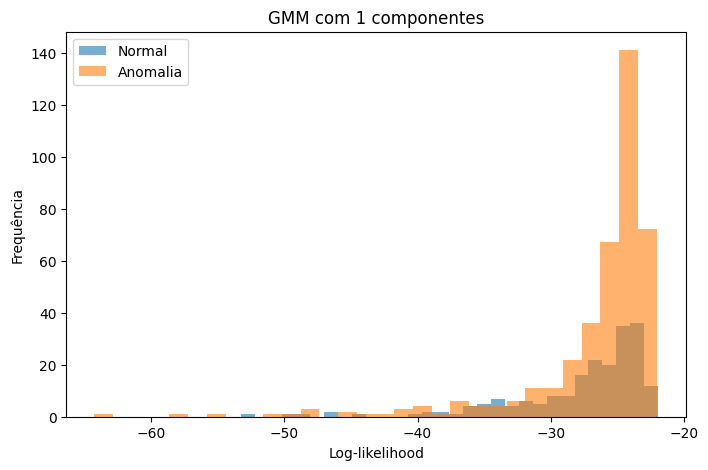

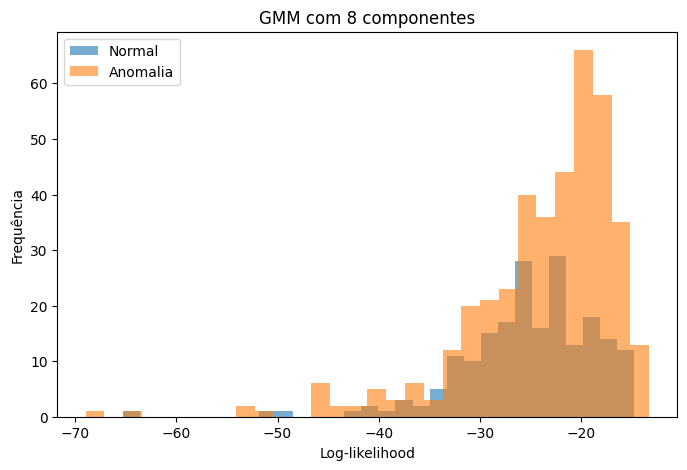

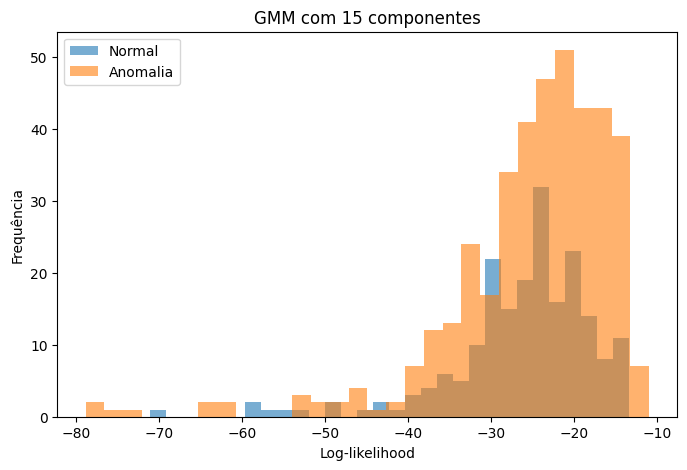

In [28]:
import matplotlib.pyplot as plt

componentes_interesse = [1, 8, 15]

for n in componentes_interesse:

    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(X_train_normal_pca)

    scores = gmm.score_samples(X_test_completo)

    scores_normais = scores[y_test_binario == 0]
    scores_anomalias = scores[y_test_binario == 1]

    plt.figure(figsize=(8, 5))

    plt.hist(
        scores_normais,
        bins=30,
        alpha=0.6,
        label='Normal'
    )

    plt.hist(
        scores_anomalias,
        bins=30,
        alpha=0.6,
        label='Anomalia'
    )

    plt.xlabel('Log-likelihood')
    plt.ylabel('Frequência')
    plt.title(f'GMM com {n} componentes')
    plt.legend()
    plt.show()

In [29]:
from sklearn.neighbors import KernelDensity

# O parâmetro bandwidth controla a "suavidade" da curva de probabilidade
kde = KernelDensity(kernel='gaussian', bandwidth=1.0)
kde.fit(X_train_normal_scaled)

scores_train_kde = kde.score_samples(X_train_normal_scaled)
scores_test_kde = kde.score_samples(X_test_completo)

limiar_kde = np.percentile(scores_train_kde, 5)

y_pred_kde = (scores_test_kde < limiar_kde).astype(int)

print("Resultados KDE:")
print(classification_report(y_test_binario, y_pred_kde))

ValueError: X has 15 features, but KernelDensity is expecting 87 features as input.